In [1]:
import sys
sys.path.append("..")
from dotenv import load_dotenv
load_dotenv("../.env")

import pandas as pd
import matplotlib.pyplot as plt
from src.db import read_sql

reg = read_sql("""SELECT algorithm, metrics FROM ml.model_registry
                  WHERE task = 'rul' ORDER BY trained_at DESC LIMIT 3""")
table = pd.concat([reg[["algorithm"]], pd.json_normalize(reg["metrics"])], axis=1)
table

,algorithm,val_rmse,test_rmse,test_nasa_score,cv_rmse
0,lstm,13.41,14.96,511.7,NaN
1,lightgbm,NaN,16.65,473.5,15.77
2,linear,NaN,22.57,1346.9,NaN


<function matplotlib.pyplot.show(close=None, block=None)>

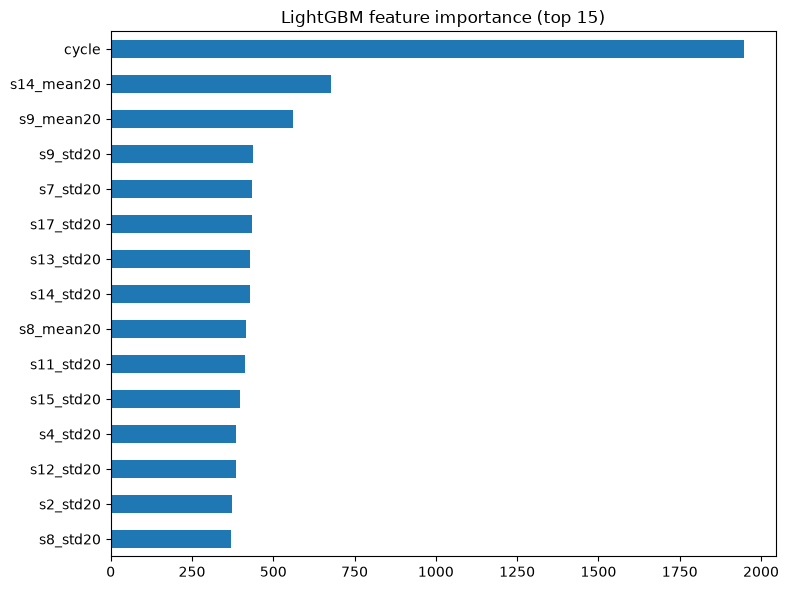

In [2]:
imp = pd.read_csv("../models/lgbm_importance_top15.csv", index_col=0).iloc[:, 0].sort_values()
imp.plot.barh(figsize=(8, 6), title="LightGBM feature importance (top 15)")
plt.tight_layout(); plt.show

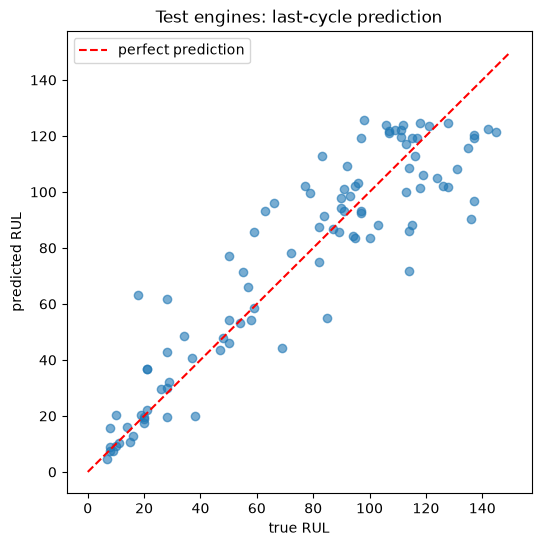

In [3]:
p = read_sql("""
    SELECT DISTINCT ON (p.unit_id) p.unit_id, p.pred_rul, f.rul_true
    FROM ml.rul_predictions p
    JOIN feat.fd001_test f ON f.unit_id = p.unit_id AND f.cycle = p.cycle
    WHERE p.split = 'test'
    ORDER BY p.unit_id, p.cycle DESC""")

plt.figure(figsize=(6, 6))
plt.scatter(p["rul_true"], p["pred_rul"], alpha=0.6)
plt.plot([0, 150], [0, 150], "r--", label="perfect prediction")
plt.xlabel("true RUL"); plt.ylabel("predicted RUL"); plt.legend()
plt.title("Test engines: last-cycle prediction")
plt.show()